# Fetch CMEMS Data

Download and cache all CMEMS datasets needed by the Baltic drifter notebooks.
The time range is derived programmatically from the science CSV produced by notebook 00.

## Imports

In [1]:
from pathlib import Path

import copernicusmarine
import pandas as pd

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

In [2]:
SCIENCE_CSV = "data/drifters_science.csv"
OUTPUT_DIR = "data/cmems"
LON_MIN = 9.0
LON_MAX = 13.0
LAT_MIN = 53.5
LAT_MAX = 56.0

## Derive time range from science data

In [3]:
df = pd.read_csv(SCIENCE_CSV, parse_dates=["date_UTC"])
time_start = df["date_UTC"].min().floor("D").strftime("%Y-%m-%d")
time_end = df["date_UTC"].max().ceil("D").strftime("%Y-%m-%d")
print(f"Derived time range: {time_start} to {time_end}")

Derived time range: 2023-04-24 to 2023-05-07


## Setup

In [4]:
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

## Physics (currents)

In [5]:
ds_phy = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_bal_phy_anfc_PT1H-i",
).sel(
    longitude=slice(LON_MIN, LON_MAX),
    latitude=slice(LAT_MIN, LAT_MAX),
    time=slice(time_start, time_end),
    depth=slice(0, 5),
)[["uo", "vo"]].load()

out_path = output_dir / "cmems_mod_bal_phy_anfc_PT1H-i.nc"
ds_phy.to_netcdf(out_path)
print(f"Physics: {dict(ds_phy.dims)}")
print(f"  {out_path.name}: {out_path.stat().st_size / 1e6:.1f} MB")

INFO - 2026-04-02T14:37:41Z - Selected dataset version: "202411"


INFO - 2026-04-02T14:37:41Z - Selected dataset part: "default"


Physics: {'time': 336, 'depth': 5, 'latitude': 150, 'longitude': 143}
  cmems_mod_bal_phy_anfc_PT1H-i.nc: 288.3 MB


/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_21268/1265898573.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Physics: {dict(ds_phy.dims)}")


## Waves

In [6]:
WAVE_VARS = [
    "VSDX", "VSDY",                        # surface Stokes drift components
    "VHM0", "VTPK",                        # total Hs and peak period
    "VHM0_WW", "VTM01_WW", "VMDR_WW",     # wind wave partition
    "VHM0_SW1", "VTM01_SW1", "VMDR_SW1",  # swell partition 1
    "VHM0_SW2", "VTM01_SW2", "VMDR_SW2",  # swell partition 2
]

ds_wav = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_bal_wav_anfc_PT1H-i",
).sel(
    longitude=slice(LON_MIN, LON_MAX),
    latitude=slice(LAT_MIN, LAT_MAX),
    time=slice(time_start, time_end),
)[WAVE_VARS].load()

out_path = output_dir / "cmems_mod_bal_wav_anfc_PT1H-i.nc"
ds_wav.to_netcdf(out_path)
print(f"Waves: {dict(ds_wav.dims)}")
print(f"  {out_path.name}: {out_path.stat().st_size / 1e6:.1f} MB")

INFO - 2026-04-02T14:38:47Z - Selected dataset version: "202311"


INFO - 2026-04-02T14:38:47Z - Selected dataset part: "default"


Waves: {'time': 336, 'latitude': 150, 'longitude': 144}
  cmems_mod_bal_wav_anfc_PT1H-i.nc: 377.5 MB


/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_21268/3710875921.py:19: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Waves: {dict(ds_wav.dims)}")


## Static (land mask)

In [7]:
ds_static = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_bal_phy_anfc_static",
    service="static-arco",
)[["mask"]].load()

out_path = output_dir / "cmems_mod_bal_phy_anfc_static.nc"
ds_static.to_netcdf(out_path)
print(f"Static: {dict(ds_static.dims)}")
print(f"  {out_path.name}: {out_path.stat().st_size / 1e6:.1f} MB")

INFO - 2026-04-02T14:39:45Z - Selected dataset version: "202411"


INFO - 2026-04-02T14:39:45Z - Selected dataset part: "bathy"


Static: {'depth': 56, 'latitude': 774, 'longitude': 763}
  cmems_mod_bal_phy_anfc_static.nc: 132.3 MB


/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_21268/4002749767.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Static: {dict(ds_static.dims)}")


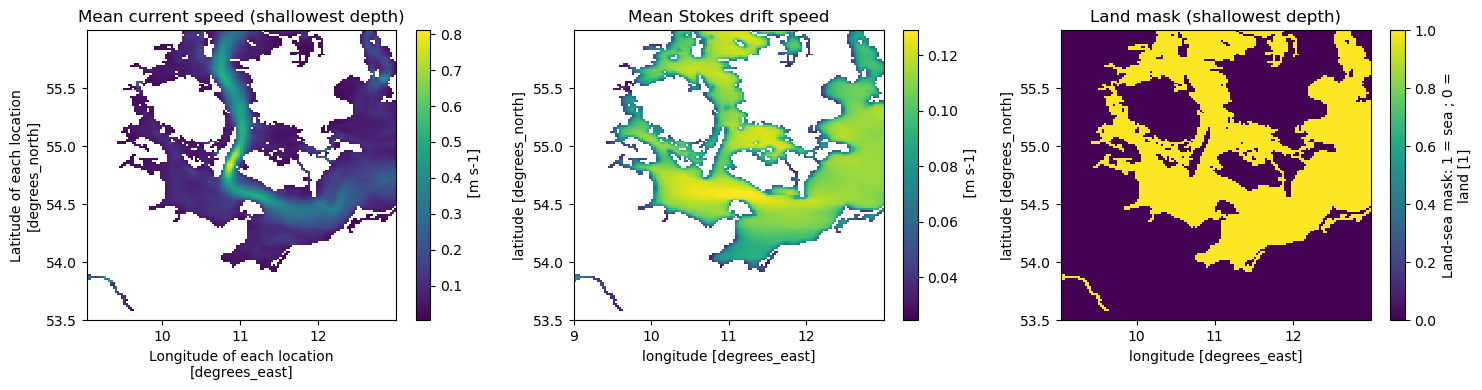

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Mean current speed at shallowest depth
current_speed = np.sqrt(ds_phy["uo"] ** 2 + ds_phy["vo"] ** 2).isel(depth=0).mean("time")

# Mean Stokes drift speed
stokes_speed = np.sqrt(ds_wav["VSDX"] ** 2 + ds_wav["VSDY"] ** 2).mean("time")

# Land mask at shallowest depth (first time step is representative)
land_mask = ds_static["mask"].sel(
    longitude=slice(LON_MIN, LON_MAX),
    latitude=slice(LAT_MIN, LAT_MAX),
).isel(depth=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

current_speed.plot(ax=axes[0])
axes[0].set_title("Mean current speed (shallowest depth)")

stokes_speed.plot(ax=axes[1])
axes[1].set_title("Mean Stokes drift speed")

land_mask.plot(ax=axes[2])
axes[2].set_title("Land mask (shallowest depth)")

plt.tight_layout()
plt.show()

## Summary

In [9]:
print("Saved files:")
for f in sorted(output_dir.glob("*.nc")):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name}: {size_mb:.1f} MB")

Saved files:
  cmems_mod_bal_phy_anfc_PT1H-i.nc: 288.3 MB
  cmems_mod_bal_phy_anfc_static.nc: 132.3 MB
  cmems_mod_bal_wav_anfc_PT1H-i.nc: 377.5 MB
  effective_currents.nc: 1750.3 MB
